In [15]:
import xarray as xr
import numpy as np
import glob
import pandas as pd
import pygmt
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.interpolate import RBFInterpolator
from scipy.ndimage import gaussian_filter
from geopy.distance import geodesic
import src.processing as cl
import src.plotting as pl

In [ ]:
#################################################
# --- CONFIGURATION ---
#to match the parameters of the tomographic inversion
#if needed, ajust the grid size and the number of points
min_max_dep=[0, 45] # depth in km
n_rtp=[121, 121, 201]
region=[-12, -2, 50, 56]
region_plot=[-11, -5, 51, 55.7]
folder = "/home/bmelo/Quarry/Eire-velocity_models/out_models/"
profile_files = sorted(glob.glob(folder + "*/*_vp.nc"))  # your .nc files
lines = pd.read_csv("/home/bmelo/Quarry/Eire-velocity_models/line_coords")

In [45]:
# --- GATHER ALL PROFILE POINTS ---
all_points = []
all_values = []

for f in profile_files:
    pf = xr.open_dataset(f)
    print(f"Processing file: {f}")

    lon = pf["lon"].values  # shape: (x,)
    lat = pf["lat"].values  # shape: (x,)
    z = pf["z"].values      # shape: (z,)
    vp = pf["vp"].values    # shape: (z, x)
    
   # --- Filter out negative depths ---
    valid_idx = z >= 0
    z = z[valid_idx]
    vp = vp[valid_idx, :]       # shape: (z, x)

    # --- Generate coordinate grids to match vp ---
    lon2d, z2d = np.meshgrid(lon, z)  # shape: (z, x)
    lat2d, _   = np.meshgrid(lat, z)  # shape: (z, x)

    # Stack into (N, 3) coordinates and flatten vp values
    all_points.append(np.column_stack([z2d.ravel(), lat2d.ravel(), lon2d.ravel()]))  # (z, lat, lon)
    all_values.append(vp.ravel())

# --- COMBINE ALL PROFILES ---
all_points = np.vstack(all_points)         # shape: (N_points, 3)
all_values = np.hstack(all_values)   # shape: (N,)

# --- DEFINE TARGET GRID ---
lon_min, lon_max = region[0], region[1]
lat_min, lat_max = region[2], region[3]
z_min, z_max = min_max_dep

Ngrid = n_rtp
lon_grid = np.linspace(lon_min, lon_max, Ngrid[0])
lat_grid = np.linspace(lat_min, lat_max, Ngrid[1])
z_grid   = np.linspace(z_min, z_max, Ngrid[2])

lons = all_points[:, 2]
lats = all_points[:, 1]

# Generate a mask: 1 for land, NaN for ocean
print("Creating grid with land mask...")
land_mask = pygmt.grdlandmask(
    region=region,
    spacing=[lon_grid[1] - lon_grid[0], lat_grid[1] - lat_grid[0]],
    maskvalues=[0, np.nan, np.nan, np.nan, np.nan],
    resolution="h",
    registration="gridline"
)

mask_values = land_mask.interp(
    lon=xr.DataArray(lons, dims="points"),
    lat=xr.DataArray(lats, dims="points"),
    method="nearest"
).values

# Final mask: True for land, False for ocean
is_land = np.isnan(mask_values)

# Apply to your data
land_points = all_points[is_land]
land_values = all_values[is_land]

Processing file: /home/bmelo/Quarry/Eire-velocity_models/out_models/COOLE/COOLE1_vp.nc
Processing file: /home/bmelo/Quarry/Eire-velocity_models/out_models/ICSSP/ICSSP_vp.nc
Processing file: /home/bmelo/Quarry/Eire-velocity_models/out_models/LEGS/LEGSA_vp.nc
Processing file: /home/bmelo/Quarry/Eire-velocity_models/out_models/LEGS/LEGSB_vp.nc
Processing file: /home/bmelo/Quarry/Eire-velocity_models/out_models/LEGS/LEGSC_vp.nc
Processing file: /home/bmelo/Quarry/Eire-velocity_models/out_models/VARNET/VARNETA_vp.nc
Processing file: /home/bmelo/Quarry/Eire-velocity_models/out_models/VARNET/VARNETB_vp.nc
Creating grid with land mask...


In [ ]:
# 1. Create 3D grid
print("Creating 3D grid...")
Z, LAT, LON = np.meshgrid(z_grid, lat_grid, lon_grid, indexing="ij")  # shape: (z, lat, lon)
interp_targets = np.column_stack([Z.ravel(), LAT.ravel(), LON.ravel()])  # shape: (N_gridpoints, 3)

# 2. Interpolate using RBF
print("Interpolating with RBF... Normal to take a while, please be patient.")
rbf = RBFInterpolator(
    land_points, land_values,
    kernel="linear",     # or "thin_plate_spline", "multiquadric"
    neighbors=40,         # adjust for performance vs. accuracy
    smoothing=1,              # helps with robustness
    epsilon=1.0
)
vp_3d = rbf(interp_targets).reshape(Z.shape)

Creating 3D grid...
Interpolating with RBF... Normal to take a while, please be patient.


In [28]:
# 3. Extrapolate and smooth
vp_filled = cl.extrapolate_bottom_constant(vp_3d, z)
vp_smooth = gaussian_filter(vp_filled, sigma=(2, 2, 2))  # (z, lat, lon)

# 4. Interpolate land mask to your lat/lon grid
lon2d, lat2d = np.meshgrid(lon_grid, lat_grid)
land_mask_interp = land_mask.interp(
    lon=xr.DataArray(lon2d, dims=["y", "x"]),
    lat=xr.DataArray(lat2d, dims=["y", "x"]),
    method="nearest"
)
land_mask_2d = np.isnan(land_mask_interp.values)

# 6. Broadcast to 3D
land_mask_3d = np.broadcast_to(land_mask_2d, vp_smooth.shape[1:])
#land_mask_3d = np.broadcast_to(land_mask_3d, vp_smooth.shape)

# 7. Apply land mask
vp_masked = np.where(land_mask_3d, vp_smooth, np.nan)

# --- SAVE TO NETCDF ---
ds_3d = xr.Dataset(
    {"vp": (("z", "lat", "lon"), vp_masked)},
    coords={"z": z_grid, "lat": lat_grid, "lon": lon_grid},
    attrs={"description": "3D Vp model (RBF interpolated and smoothed)"}
)
ds_3d.to_netcdf(folder + "interpolated/vp_3d_rbf.nc")
print("Saved 3D velocity model to vp_3d_rbf.nc.")

Saved 3D velocity model to vp_3d_rbf.nc.


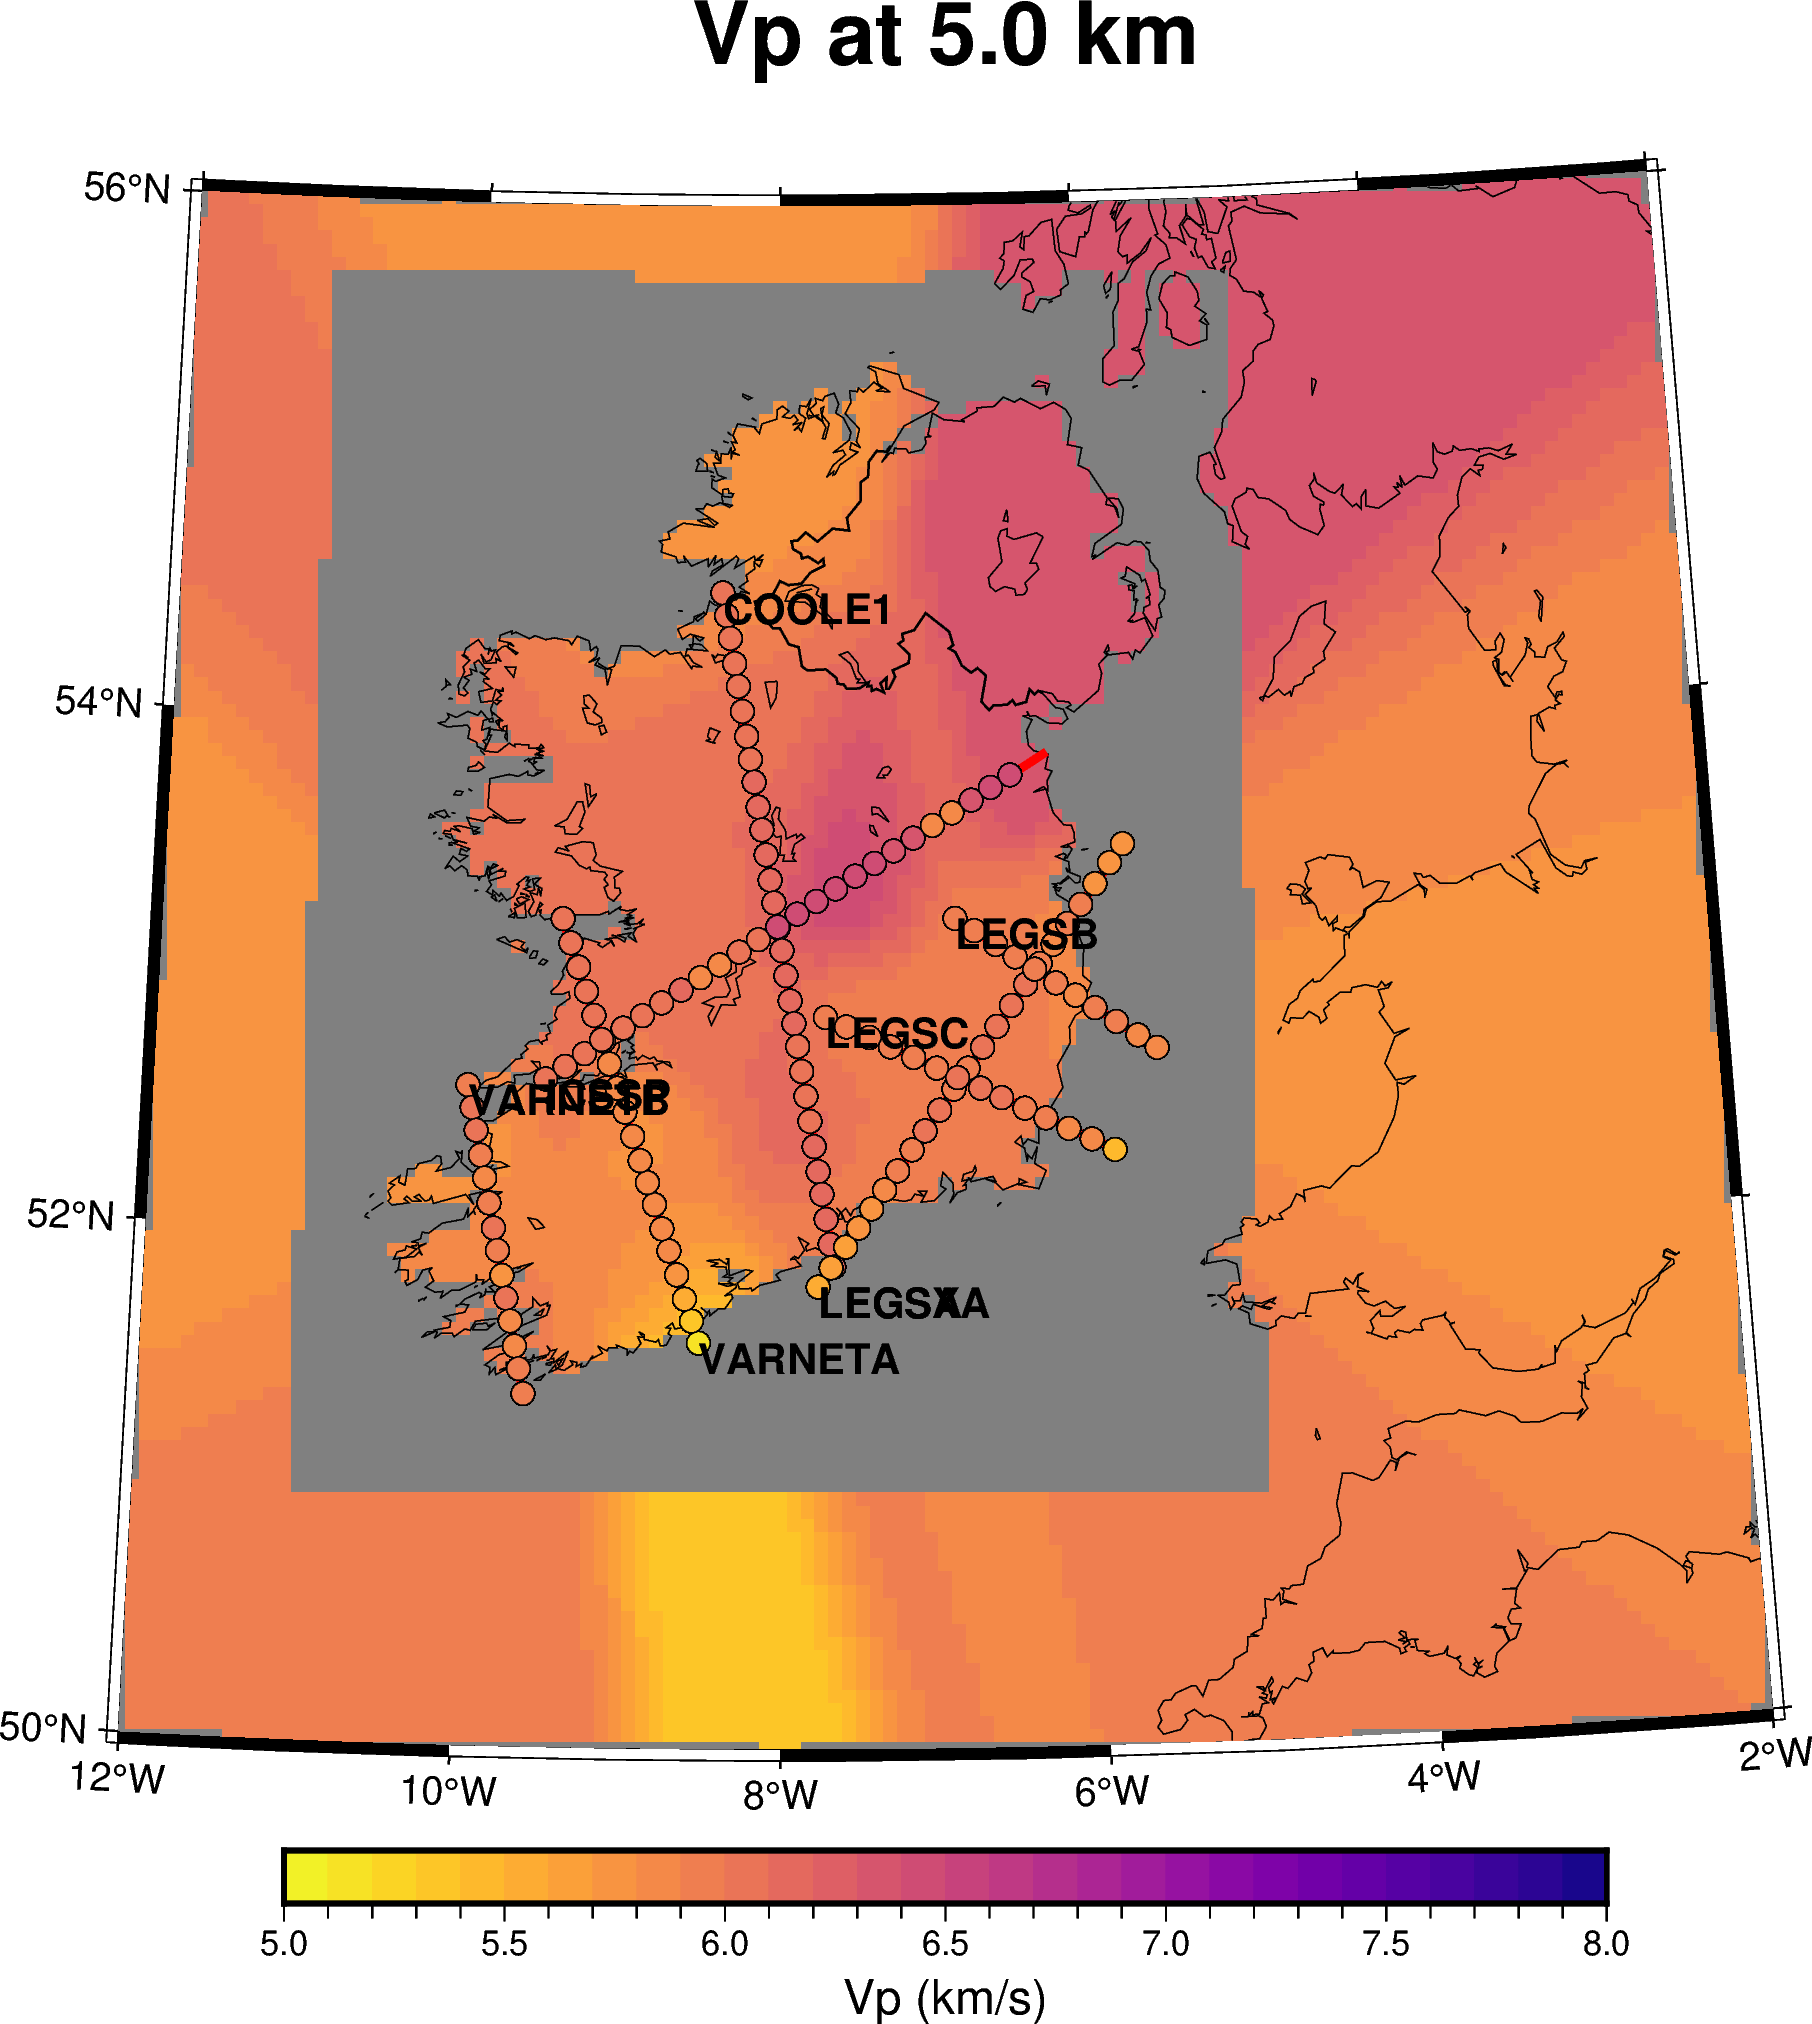

In [44]:
#visualize interpolation

target_depth = 5.0  # km
depth_tol = 0.5     # km tolerance window
sample_spacing_km = 10.0

# Collect original Vp sample points at target depth ± tol
scatter_points = []

for path in profile_files:
    #print(f"Processing file: {path}")
    ds_2d = xr.open_dataset(path)
    lat = ds_2d["lat"].values
    lon = ds_2d["lon"].values
    z   = ds_2d["z"].values
    vp  = ds_2d["vp"].values  # shape (z, x)
    #print(max(z))

    # Find indices of depth levels close to target depth
    close_depths = np.where(np.abs(z - target_depth) <= depth_tol)[0]

    for zi in close_depths:
        last_sample_point = None
        for j in range(len(lon)):
            point = (lat[j], lon[j])
            if last_sample_point is None or geodesic(point, last_sample_point).km >= sample_spacing_km:
                scatter_points.append([lon[j], lat[j], vp[zi, j]])
                last_sample_point = point

# Convert to DataFrame
df_scatter = pd.DataFrame(scatter_points, columns=["lon", "lat", "vp"])

ds = xr.open_dataset(folder + "interpolated/vp_3d_rbf.nc")
#ds = ds_3d
lat = ds["lat"].values
lon = ds["lon"].values
z   = ds["z"].values
vp = ds["vp"].transpose("z", "lat", "lon").values

depth_idx = (np.abs(z - target_depth)).argmin()
vp_slice = vp[depth_idx, :, :]  # (lat, lon)
# Confirm values exist

# --- Save temporary grid file ---
temp_grd = folder + "vp_slice.grd"
ds_slice = xr.Dataset(
    {"vp": (("lat", "lon"), vp_slice)},
    coords={"lat": lat, "lon": lon}
)
#ds_slice.to_netcdf(temp_grd)

# --- Plot with PyGMT ---
fig = pygmt.Figure()
#region=[-11, -5, 51, 56]
fig.basemap(
    region=region,
    projection="L-8/53.5/49.5/53.5/14c",
    frame=["a", f"+tVp at {z[depth_idx]:.1f} km"]
)

pygmt.makecpt(cmap="plasma", series=[5, 8, 0.1], background=True, reverse=True)#, continuous=True)
fig.grdimage(grid=ds_slice["vp"], shading=False)

fig.coast(shorelines=True, borders="1/0.5p,black", resolution="i")#, water="white")
fig.colorbar(frame='af+lVp (km/s)')

# Plot each line
for _, row in lines.iterrows():
    fig.plot(x=[row["start_lon"], row["end_lon"]],
             y=[row["start_lat"], row["end_lat"]],
             pen="2p,red",
             label=row["tag"]) 

# Overlay Vp sample points at target depth
fig.plot(
    x=df_scatter["lon"],
    y=df_scatter["lat"],
    style="c0.2c",
    fill=df_scatter["vp"],
    cmap=True,
    pen="black",
)

# Optionally annotate line names at midpoints
for _, row in lines.iterrows():
    mid_lon = (row["start_lon"] + row["end_lon"]) / 2
    mid_lat = (row["start_lat"] + row["end_lat"]) / 2
    fig.text(x=row["start_lon"],
             y=row["start_lat"], 
             text=row["tag"], 
             font="10p,Helvetica-Bold,black", 
             justify="LT")
    
fig.show()

Calculate and plot 1D velocity average...


/tmp/ipykernel_1366443/851750351.py:23: RuntimeWarning: Mean of empty slice
  vp_2d_avg = np.nanmean(vp_2d, axis=1)  # Average over horizontal axis
/tmp/ipykernel_1366443/851750351.py:39: RuntimeWarning: Mean of empty slice
  vp_mean_all = np.nanmean(vp_interp_all, axis=0)  # shape: (n_depths,)


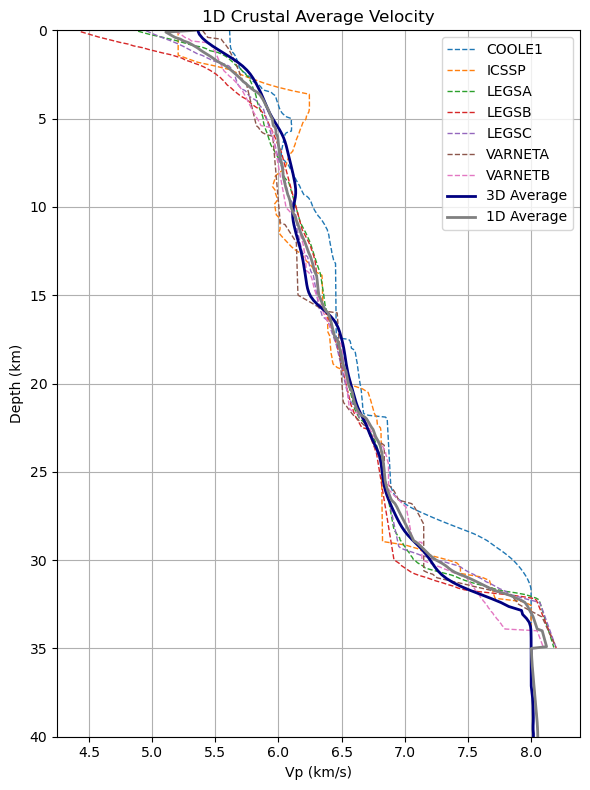

<Figure size 640x480 with 0 Axes>

In [33]:
print("Calculate and plot 1D velocity average...")

#1D velocity average
#ds = ds_3d  # adjust if needed
vp = ds["vp"].values    # (z, lat, lon)
lat = ds["lat"].values
lon = ds["lon"].values
z   = ds["z"].values
vp_1d = np.nanmean(vp, axis=(1, 2))  # shape: (z,)

# --- Compute velocity averages for each 2D profile ---
profile_averages = []
all_depths = []

for f in profile_files:
    ds_2d = xr.open_dataset(f)
    tag=f.split("/")[-1].split("_")[0]  # Extract tag from filename
    z_2d = ds_2d["z"].values
    vp_2d = ds_2d["vp"].values  # shape: (z, x)
    valid_idx = z_2d >= 0  # Filter out negative depths
    z_2d = z_2d[valid_idx]
    vp_2d = vp_2d[valid_idx, :]
    vp_2d_avg = np.nanmean(vp_2d, axis=1)  # Average over horizontal axis
    profile_averages.append((z_2d, vp_2d_avg, tag))
    all_depths.append(z_2d)

# Interpolate all profile averages onto the common grid
vp_interp_all = []
dz = 0.1
z_common = np.arange(min_max_dep[0], min_max_dep[1] + dz, dz)

for z_2d, vp_2d, _ in profile_averages:
    f_interp = interp1d(z_2d, vp_2d, bounds_error=False, fill_value=np.nan)
    vp_interp_all.append(f_interp(z_common))

vp_interp_all = np.vstack(vp_interp_all)  # shape: (n_profiles, n_depths)

# Compute mean across all profiles
vp_mean_all = np.nanmean(vp_interp_all, axis=0)  # shape: (n_depths,)

# --- Plot the result ---
plt.figure(figsize=(6, 8))
for i, (z_2d, vp_2d_avg, tag) in enumerate(profile_averages):
    plt.plot(vp_2d_avg, z_2d, linestyle='--' ,lw=1, label=tag)
plt.plot(vp_1d, z, color='navy', lw=2, label="3D Average")
plt.plot(vp_mean_all, z_common, color='gray', lw=2, label="1D Average")
plt.gca().invert_yaxis()
plt.xlabel("Vp (km/s)")
plt.ylabel("Depth (km)")
plt.ylim(40,0)
plt.grid(True)
plt.title("1D Crustal Average Velocity")
plt.legend()
plt.tight_layout()
plt.show()

plt.savefig(folder + "interpolated/1D_crustal_average_velocity.png", dpi=300)

In [34]:
print("Saving 1D velocity model to ASCII file...")
Ngrid = n_rtp
# Create custom ASCII file in the format lon, lat, dep, velocity
with open(folder + "interpolated/vp_1d_full.txt", "w") as f:
    for k in range(Ngrid[2]):
        for j in range(Ngrid[1]):
            for i in range(Ngrid[0]):
                if not np.isnan(vp_1d[k]):  # Only include non-NaN values
                    f.write(f"{lon[i]} {lat[j]} {z[k]} {vp_1d[k]}\n")
                    
with open(folder + "interpolated/vp_1d_simple.txt", "w") as f:
    for k in range(Ngrid[2]):
        if not np.isnan(vp_1d[k]):
            f.write(f"{z[k]} {vp_1d[k]}\n")

Saving 1D velocity model to ASCII file...


lat


/tmp/ipykernel_1366443/2520901272.py:51: RuntimeWarning: Mean of empty slice
  vp_mean = np.nanmean(section_ds["vp"].values, axis=1)  # mean along the horizontal axis (lat or lon)


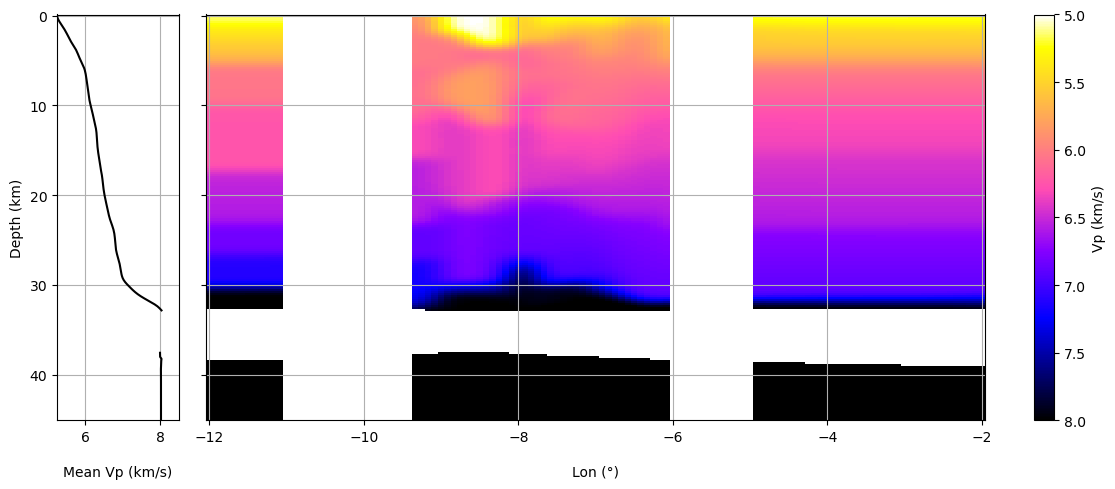

In [43]:
def plot_velocity_section(ncfile, mode="lon", value=None, cmap="jet", title=None):
    """
    Plot a vertical velocity section at constant latitude or longitude.

    Parameters:
        ncfile (str): Path to NetCDF file with 'vp(z, lat, lon)'.
        mode (str): 'lon' (default) for lat–depth section, or 'lat' for lon–depth section.
        value (float): The lon or lat value where to slice.
        cmap (str): GMT colormap name.
        title (str): Optional title for the plot.

    Example:
        plot_velocity_section("vp_3d_rbf.nc", mode="lon", value=-9.0)
    """
    #ds = xr.open_dataset(ncfile)
    ds=ncfile
    vp = ds["vp"].transpose("z", "lat", "lon").values
    lat = ds["lat"].values
    lon = ds["lon"].values
    z = ds["z"].values

    # Determine slice
    if mode == "lon":
        if value is None:
            value = lon[len(lon)//2]
        ix = np.abs(lon - value).argmin()
        vp_slice = vp[:, :, ix]  # shape: (z, lat)
        coords = {"z": z, "lat": lat}
        dims = ("z", "lat")
        region = [lat.min(), lat.max(), z.min(), z.max()]
        xlabel = "Latitude"
    elif mode == "lat":
        print("lat")
        if value is None:
            value = lat[len(lat)//2]
        iy = np.abs(lat - value).argmin()
        vp_slice = vp[:, iy, :]  # shape: (z, lon)
        coords = {"z": z, "lon": lon}
        dims = ("z", "lon")
        region = [lon.min(), lon.max(), z.min(), z.max()]
        xlabel = "Longitude"
    else:
        raise ValueError("mode must be 'lon' or 'lat'")

    # Temporary NetCDF for PyGMT
    section_ds = xr.Dataset({"vp": (dims, vp_slice)}, coords=coords)
    section_file = "interpolated/vp_section.nc"
    section_ds.to_netcdf(folder + section_file)
    
    # Compute 1D velocity average at each depth
    vp_mean = np.nanmean(section_ds["vp"].values, axis=1)  # mean along the horizontal axis (lat or lon)

    # --- PLOTTING ---
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5), gridspec_kw={"width_ratios": [1, 8]}, sharey=True)
    # Add 1D velocity average on right
    ax1.plot(vp_mean, section_ds["z"].values, color="black", linewidth=1.5, label="Mean Vp")
    ax2.invert_yaxis()
    ax1.set_ylabel("Depth (km)")
    ax1.set_xlim(min(vp_mean), 8.5)  # Adjust if needed
    ax1.set_xlabel("Mean Vp (km/s)", labelpad=15)
    ax1.grid(True)
    
    # Cross-section plot (2D)
    img = ax2.pcolormesh(section_ds["lat"] if "lat" in section_ds.dims else section_ds["lon"],
                         section_ds["z"],
                         section_ds["vp"],
                         shading="auto",
                         cmap='gnuplot2_r',
                         vmin=5.0, vmax=8.0)
    ax2.set_xlabel("Lat (°)" if "lat" in section_ds.dims else "Lon (°)", labelpad=15)
    ax2.grid(True)
    # Colorbar (attached to 2D plot)
    cbar = plt.colorbar(img, ax=ax2, label="Vp (km/s)")
    cbar.ax.invert_yaxis()

    plt.tight_layout()
    plt.show()
    
# --- Choose a fixed longitude for the section ---
#vp_grd = "/home/bmelo/bin/SeisBlast/1D_velocity/3D-model/vp_3d_rbf.nc"
plot_velocity_section(ds, mode="lat", value=53)

In [ ]:
ds = ds_3d  # drop empty depth levels
# --- Load NetCDF velocity model ---
#ds = xr.open_dataset("vp_3d_rbf.nc")  # adjust path
vp = ds["vp"].transpose("z", "lat", "lon").values
lat = ds["lat"].values
lon = ds["lon"].values
z   = ds["z"].values

# --- Create a 3D grid for the land mask ---
# Define Ngrid based on the shapes of lon, lat, and z
Ngrid = n_rtp

# Create custom ASCII file in the format lon, lat, dep, velocity
with open(folder + "vp_3d_full.txt", "w") as f:
    for k in range(Ngrid[2]):
        for j in range(Ngrid[1]):
            for i in range(Ngrid[0]):
                if not np.isnan(vp[k, j, i]):  # Only include non-NaN values
                    f.write(f"{lon[i]} {lat[j]} {z[k]} {vp[k, j, i]}\n")


KeyboardInterrupt: 